## 1. Load Data & Overview

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('clean_cafe_sales.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
print('Shape:', df.shape)
df.head()

Shape: (9540, 12)


In [ ]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method               object
Location                     object
Transaction Date     datetime64[ns]
Year                          int64
Month                         int64
Month Name                  object
Day of Week                  object
dtype: object

## 2. Data Quality Check (Missing & 'Unknown' Values)

The dataset uses the string `"Unknown"` instead of nulls, so we check for it separately from `isna()`.

In [ ]:
print('Null values per column:')
print(df.isna().sum())
print()
print('Duplicate Transaction IDs:', df['Transaction ID'].duplicated().sum())

Null values per column:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Year                0
Month               0
Month Name          0
Day of Week         0
dtype: int64

Duplicate Transaction IDs: 0


In [ ]:
for c in ['Item', 'Payment Method', 'Location']:
    n_unknown = (df[c] == 'Unknown').sum()
    pct = n_unknown / len(df) * 100
    print(f'{c:15s}: {n_unknown:5d} Unknown  ({pct:.1f}%)')

mask_any = (df['Item']=='Unknown') | (df['Payment Method']=='Unknown') | (df['Location']=='Unknown')
print(f'\nRows with at least one Unknown field: {mask_any.sum()} ({mask_any.mean()*100:.1f}%)')

Item           :   456 Unknown  (4.8%)
Payment Method : 3015 Unknown  (31.6%)
Location       : 3779 Unknown  (39.6%)

Rows with at least one Unknown field: 5759 (60.4%)


## 3. Descriptive Statistics

In [ ]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

          Quantity  Price Per Unit  Total Spent
count  9540.000000     9540.000000  9540.000000
mean      3.021384        2.947307     8.919025
std       1.427099        1.278917     6.626060
min       1.000000        1.000000     1.000000
25%       2.000000        2.000000     4.000000
50%       3.000000        3.000000     8.000000
75%       4.000000        4.000000    12.000000
max       5.000000        5.000000    25.000000

In [ ]:
total_revenue = df['Total Spent'].sum()
avg_order = df['Total Spent'].mean()
total_qty = df['Quantity'].sum()
print(f'Total revenue:      ${total_revenue:,.1f}')
print(f'Total transactions: {len(df):,}')
print(f'Total items sold:   {total_qty:,.0f}')
print(f'Avg order value:    ${avg_order:.2f}')

Total revenue:      $85,087.5
Total transactions: 9,540
Total items sold:   28,824
Avg order value:    $8.92


## 4. Business Questions

### Q1: Which products generate the most revenue?

In [ ]:
item_stats = df.groupby('Item').agg(
    revenue=('Total Spent', 'sum'),
    qty=('Quantity', 'sum'),
    orders=('Transaction ID', 'count'),
    avg_price=('Price Per Unit', 'mean')
).sort_values('revenue', ascending=False)
item_stats

          revenue     qty  orders  avg_price
Item                                        
Salad     18236.0  3650.0    1216   5.000000
Sandwich  13080.0  3277.0    1075   3.995349
Smoothie  12792.0  3200.0    1048   3.996183
Juice     10049.0  3350.0    1124   3.000000
Cake       9841.0  3284.0    1082   3.000000
Coffee     7572.0  3781.0    1246   2.000000
Tea        5169.5  3444.0    1142   1.500000
Unknown    4905.0  1405.0     456   3.473684
Cookie     3443.0  3433.0    1151   1.000000

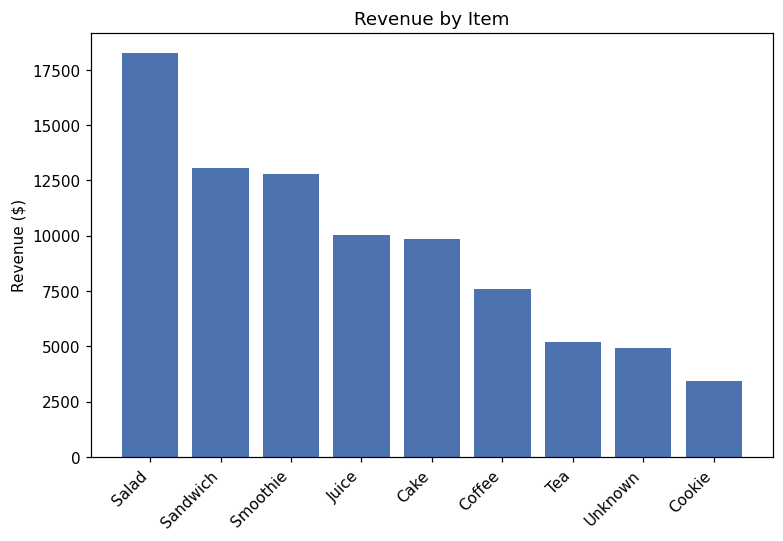

In [ ]:
item_stats['revenue'].plot(kind='bar', figsize=(8,5), color='#4C72B0', title='Revenue by Item')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer**: `Salad` generates the most revenue ($18,236), even though `Coffee` and `Cookie` sell in higher quantities — because their unit price is much lower ($2 and $1). This points to a pricing/bundling opportunity on the cheap, high-volume items.

### Q2: Is there a meaningful difference between In-store and Takeaway sales?

In [ ]:
loc_stats = df[df['Location'] != 'Unknown'].groupby('Location').agg(
    revenue=('Total Spent', 'sum'), orders=('Transaction ID', 'count')
).sort_values('revenue', ascending=False)
loc_stats

          revenue  orders
Location                 
In-store  25953.5    2872
Takeaway  25419.5    2889

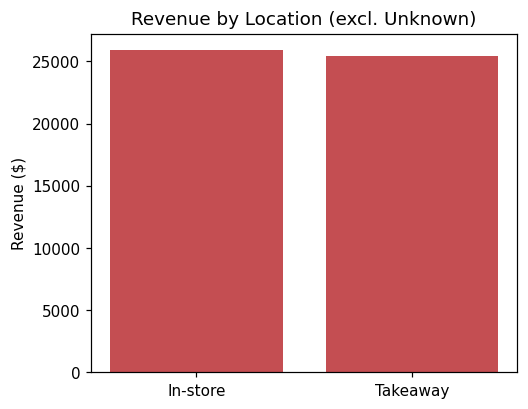

In [ ]:
loc_stats['revenue'].plot(kind='bar', figsize=(5,4), color='#C44E52', title='Revenue by Location (excl. Unknown)')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Answer**: No meaningful difference — revenue and order counts are almost identical between the two channels.

### Q3: Does payment method affect sales?

In [ ]:
pm_stats = df[df['Payment Method'] != 'Unknown'].groupby('Payment Method').agg(
    revenue=('Total Spent', 'sum'), orders=('Transaction ID', 'count')
).sort_values('revenue', ascending=False)
pm_stats

                revenue  orders
Payment Method                 
Digital Wallet  19581.0    2197
Cash            19563.0    2158
Credit Card     19523.5    2170

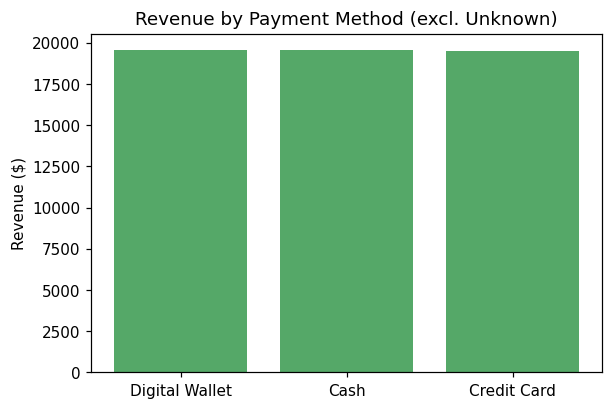

In [ ]:
pm_stats['revenue'].plot(kind='bar', figsize=(6,4), color='#55A868', title='Revenue by Payment Method (excl. Unknown)')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Answer**: All three payment methods are nearly identical in revenue and order count — no dominant payment method.

### Q4: Is there monthly seasonality?

In [ ]:
monthly = df.groupby(['Month', 'Month Name']).agg(
    revenue=('Total Spent', 'sum'), orders=('Transaction ID', 'count')
).reset_index().sort_values('Month')
monthly

    Month Month Name  revenue  orders
0       1    January   7274.0     818
1       2   February   6654.0     727
2       3      March   7224.0     827
3       4      April   7202.0     774
4       5        May   6989.5     777
5       6       June   7361.0     818
6       7       July   6893.5     791
7       8     August   7120.5     803
8       9  September   6875.0     788
9      10    October   7318.0     838
10     11   November   6967.0     784
11     12   December   7209.0     795

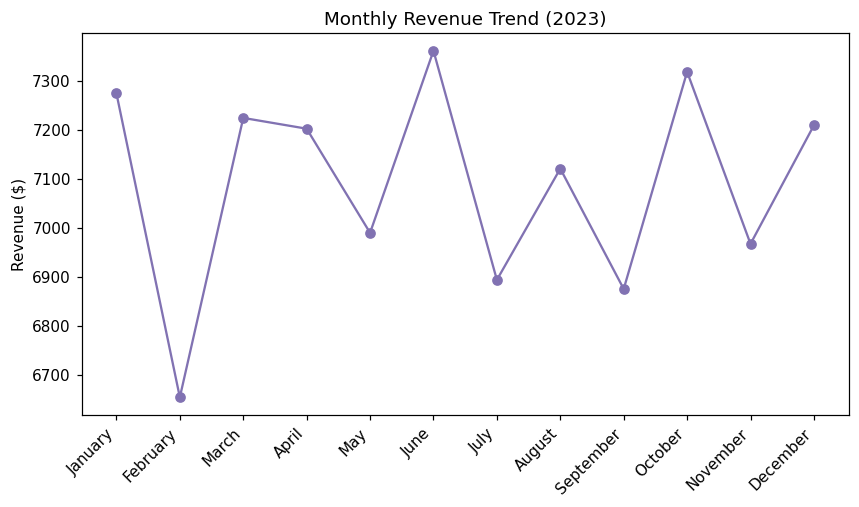

In [ ]:
plt.figure(figsize=(9,4.5))
plt.plot(monthly['Month Name'], monthly['revenue'], marker='o', color='#8172B2')
plt.title('Monthly Revenue Trend (2023)')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer**: No clear seasonality — monthly revenue only ranges between $6,654 and $7,361 (less than a 10% spread).

### Q5: Are some days of the week stronger than others?

In [ ]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = df.groupby('Day of Week').agg(
    revenue=('Total Spent', 'sum'), orders=('Transaction ID', 'count')
).reindex(dow_order)
dow_stats

              revenue  orders
Day of Week                  
Monday       12164.0    1382
Tuesday      12062.5    1311
Wednesday    11696.5    1341
Thursday     12435.5    1380
Friday       12370.0    1388
Saturday     12055.5    1358
Sunday       12303.5    1380

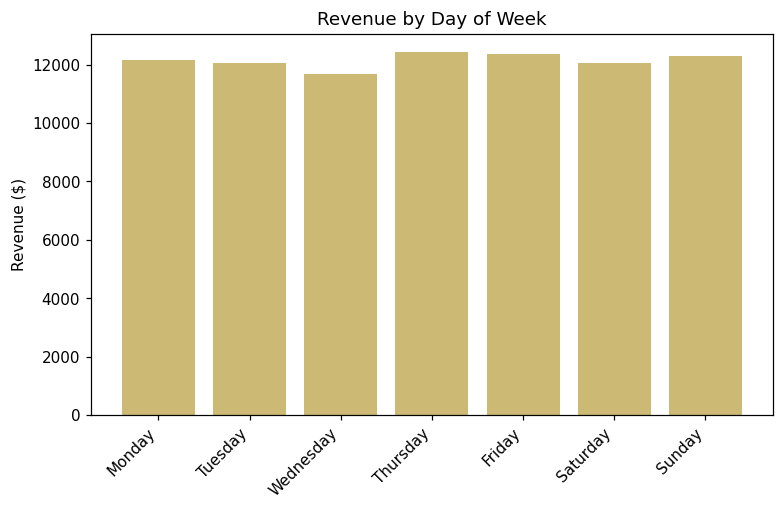

In [ ]:
dow_stats['revenue'].plot(kind='bar', figsize=(8,4.5), color='#CCB974', title='Revenue by Day of Week')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer**: All days of the week are very close (less than a 7% spread between the highest and lowest day) — no real peak day.

### Q6: Is the quantity per order naturally distributed or random?

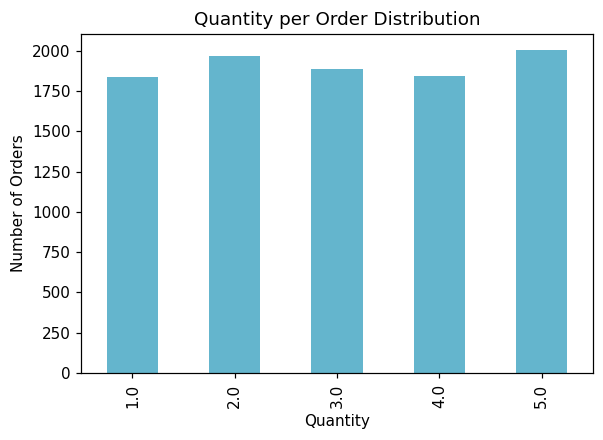

In [ ]:
df['Quantity'].value_counts().sort_index().plot(kind='bar', figsize=(6,4), color='#64B5CD',
                                                  title='Quantity per Order Distribution')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Observation**: The distribution is nearly flat (each value from 1 to 5 appears roughly 1,800–2,000 times) — another sign that this dataset may be **synthetically generated** rather than reflecting real customer behavior.

### Q7: How is the order value (basket size) distributed — mostly small or large orders?

In [ ]:
df['Total Spent'].describe()

count    9540.000000
mean        8.919025
std         5.997568
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        25.000000
Name: Total Spent, dtype: float64

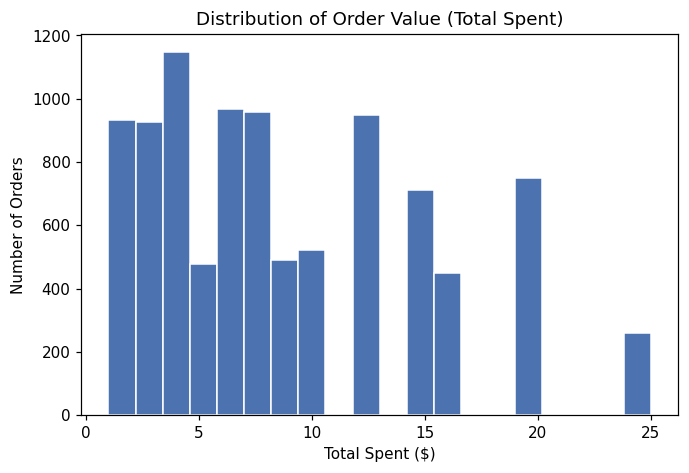

In [ ]:
plt.figure(figsize=(7,4.5))
plt.hist(df['Total Spent'], bins=20, color='#4C72B0', edgecolor='white')
plt.title('Distribution of Order Value (Total Spent)')
plt.xlabel('Total Spent ($)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Answer**: Order values range from $1 to $25, with a median of $8 and mean of $8.92 — close together, so there's no heavy skew toward very large or very small orders; most orders fall between $4 and $12 (the 25th–75th percentile range).

### Q8: Which items are typically bought in bulk (highest quantity per order)?

In [ ]:
avg_qty = df.groupby('Item').agg(orders=('Transaction ID','count'), qty=('Quantity','sum'))
avg_qty['avg_qty_per_order'] = avg_qty['qty'] / avg_qty['orders']
avg_qty.sort_values('avg_qty_per_order', ascending=False)

          orders     qty  avg_qty_per_order
Item                                       
Unknown      456  1405.0           3.081140
Smoothie    1048  3200.0           3.053435
Sandwich    1075  3277.0           3.048372
Cake        1082  3284.0           3.035120
Coffee      1246  3781.0           3.034510
Tea         1142  3444.0           3.015762
Salad       1216  3650.0           3.001645
Cookie      1151  3433.0           2.982624
Juice       1124  3350.0           2.980427

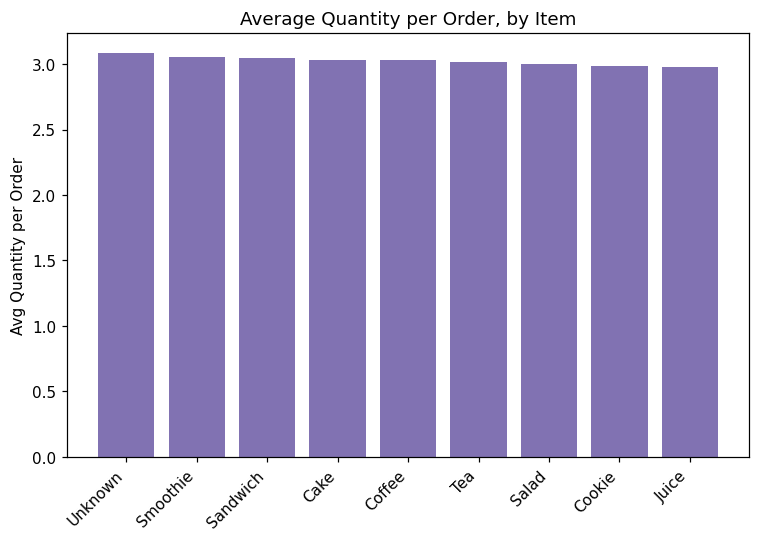

In [ ]:
avg_qty_sorted = avg_qty.sort_values('avg_qty_per_order', ascending=False).drop('Unknown')
avg_qty_sorted['avg_qty_per_order'].plot(kind='bar', figsize=(8,5), color='#8172B2',
                                          title='Average Quantity per Order, by Item')
plt.ylabel('Avg Quantity per Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer**: Average quantity per order is nearly identical across all items (about 3.0 units), ranging only from 2.98 to 3.05. There's no item that's distinctly a 'bulk buy' — another sign of randomly generated quantities rather than real purchasing patterns.

### Q9: How much of total revenue is affected by 'Unknown' data quality issues?

In [ ]:
total_rev = df['Total Spent'].sum()
for c in ['Item', 'Payment Method', 'Location']:
    rev_unknown = df.loc[df[c] == 'Unknown', 'Total Spent'].sum()
    print(f'{c:15s}: ${rev_unknown:,.1f}  ({rev_unknown/total_rev*100:.1f}% of total revenue)')

mask_any = (df['Item']=='Unknown') | (df['Payment Method']=='Unknown') | (df['Location']=='Unknown')
rev_any = df.loc[mask_any, 'Total Spent'].sum()
print(f'\nRevenue tied to rows with ANY Unknown field: ${rev_any:,.1f} ({rev_any/total_rev*100:.1f}%)')

Item           : $4,905.0  (5.8% of total revenue)
Payment Method : $26,420.0  (31.1% of total revenue)
Location       : $33,714.5  (39.6% of total revenue)

Revenue tied to rows with ANY Unknown field: $51,629.0 (60.7%)


**Answer**: 60.7% of total revenue ($51,629 out of $85,087.5) comes from transactions with at least one Unknown field. This is a major data quality risk — most financial reporting built on `Payment Method` or `Location` breakdowns is only based on ~40–68% of actual revenue.

### Q10: Is there a relationship between payment method and location?

In [ ]:
clean = df[(df['Payment Method'] != 'Unknown') & (df['Location'] != 'Unknown')]
pivot = clean.pivot_table(index='Payment Method', columns='Location',
                           values='Total Spent', aggfunc='sum')
pivot

Location        In-store  Takeaway
Payment Method                    
Cash              6148.0    5635.5
Credit Card       5731.5    5679.0
Digital Wallet    6276.0    6066.5

**Answer**: No strong relationship — revenue is spread almost evenly across every payment-method × location combination, each landing around $5,700–$6,300. Customers don't favor a particular payment method for a particular channel.